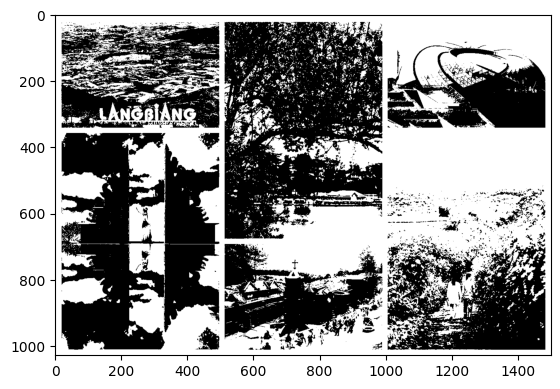

In [1]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_otsu

# Đọc ảnh và chuyển sang ảnh xám
data = Image.open('exercise/dalat.jpg').convert('L')

# Chuyển ảnh sang mảng numpy
a = np.asarray(data)

# Thực hiện ngưỡng Otsu
thres = threshold_otsu(a)

# Giữ lại các pixel có giá trị lớn hơn ngưỡng
b = a > thres

# Chuyển lại thành ảnh để hiển thị
b = Image.fromarray((b * 255).astype(np.uint8))

# Hiển thị ảnh kết quả
plt.imshow(b, cmap='gray')
plt.show()


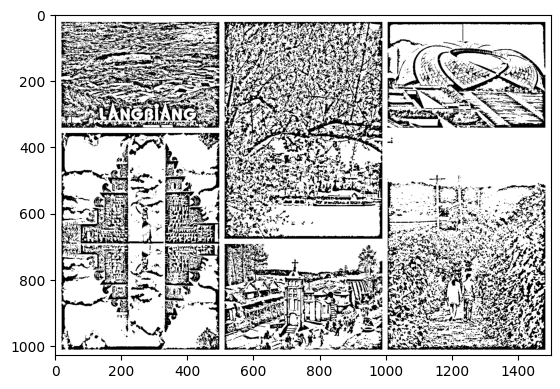

In [2]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# Đọc ảnh và chuyển sang ảnh xám
data = Image.open('exercise/dalat.jpg').convert('L')

# Chuyển ảnh thành mảng numpy
a = np.asarray(data)

# Thực hiện local thresholding (cửa sổ kích thước 39, offset = 10)
thresh = threshold_local(a, 39, offset=10)

# So sánh để tạo ảnh nhị phân
b = a > thresh

# Chuyển lại thành ảnh để hiển thị (nhân 255 để có giá trị 0/255)
b = Image.fromarray((b * 255).astype(np.uint8))

# Hiển thị ảnh kết quả
plt.imshow(b, cmap='gray')
plt.show()


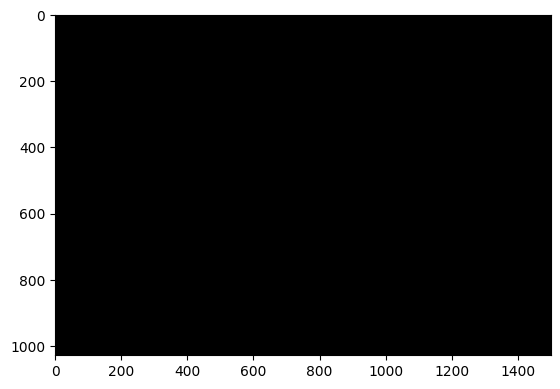

In [3]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# Mở ảnh và chuyển sang ảnh xám
data = cv2.imread('exercise/dalat.jpg')
a = cv2.cvtColor(data, cv2.COLOR_BGR2GRAY)

# Ngưỡng Otsu (nhị phân đảo)
thresh, b1 = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Do phương pháp Otsu chia quá nhiều, nên thực hiện co lại (erosion)
b2 = cv2.erode(b1, None, iterations=2)

# Tính khoảng cách transform
dist_trans = cv2.distanceTransform(b2, 2, 3)

# Ngưỡng ảnh distance transform để lấy vùng foreground
thresh, dt = cv2.threshold(dist_trans, 1, 255, cv2.THRESH_BINARY)

# Gán nhãn
labelled, ncc = label(dt)

# Chuyển sang kiểu int32 (yêu cầu của watershed)
labelled = labelled.astype(np.int32)

# Thực hiện watershed
cv2.watershed(data, labelled)

# Chuyển kết quả thành ảnh hiển thị
b = Image.fromarray((labelled * (255 // labelled.max())).astype(np.uint8))

# Hiển thị kết quả
plt.imshow(b, cmap='gray')
plt.show()


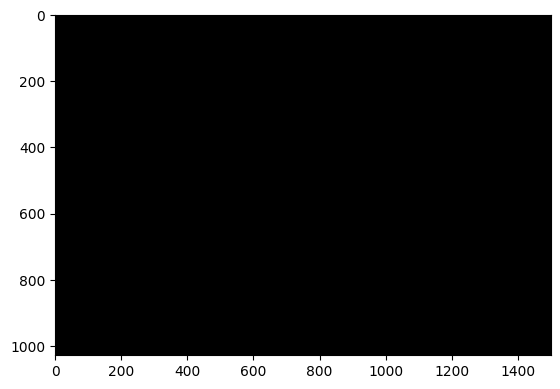

In [4]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# Mở ảnh và chuyển sang ảnh xám
data = Image.open('exercise/dalat.jpg').convert('L')

# Thực hiện phép giãn ảnh (dilation) 50 lần
b = nd.binary_dilation(np.array(data), iterations=50)

# Chuyển kết quả về ảnh để hiển thị
c = Image.fromarray((b * 255).astype(np.uint8))

# Hiển thị kết quả
c.show()           # Hiển thị bằng trình xem ảnh mặc định
plt.imshow(c, cmap='gray')  # Hiển thị bằng matplotlib
plt.show()


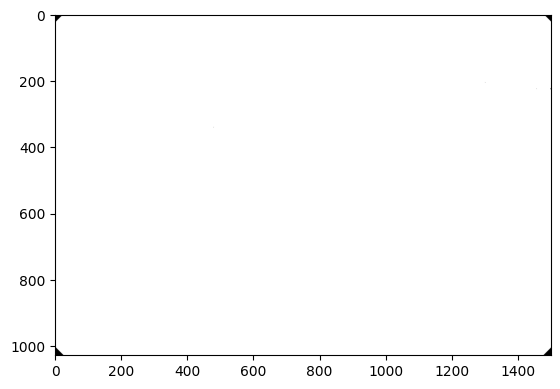

In [5]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# Mở ảnh và chuyển sang ảnh xám
data = Image.open('exercise/dalat.jpg').convert('L')

# Chuyển ảnh thành mảng numpy
data_np = np.array(data)

# Định nghĩa phần tử cấu trúc (structuring element)
s = np.array([[0, 1, 0],
              [1, 1, 1],
              [0, 1, 0]])

# Thực hiện phép mở (opening) 25 lần
b = nd.binary_opening(data_np, structure=s, iterations=25)

# Chuyển kết quả thành ảnh để hiển thị
c = Image.fromarray((b * 255).astype(np.uint8))

# Hiển thị kết quả
c.show()               # Hiển thị bằng trình xem ảnh mặc định
plt.imshow(c, cmap='gray')   # Hiển thị bằng matplotlib
plt.show()


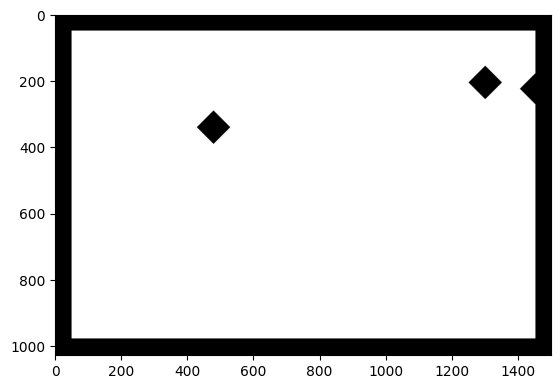

In [6]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# Mở ảnh và chuyển sang ảnh xám
data = Image.open('exercise/dalat.jpg').convert('L')

# Chuyển ảnh sang mảng numpy
data_np = np.array(data)

# Định nghĩa phần tử cấu trúc (structuring element)
s = np.array([[0, 1, 0],
              [1, 1, 1],
              [0, 1, 0]])

# Thực hiện phép co (erosion) 50 lần
b = nd.binary_erosion(data_np, structure=s, iterations=50)

# Chuyển kết quả thành ảnh để hiển thị
c = Image.fromarray((b * 255).astype(np.uint8))

# Hiển thị kết quả
c.show()               # Hiển thị bằng trình xem ảnh mặc định
plt.imshow(c, cmap='gray')   # Hiển thị bằng matplotlib
plt.show()


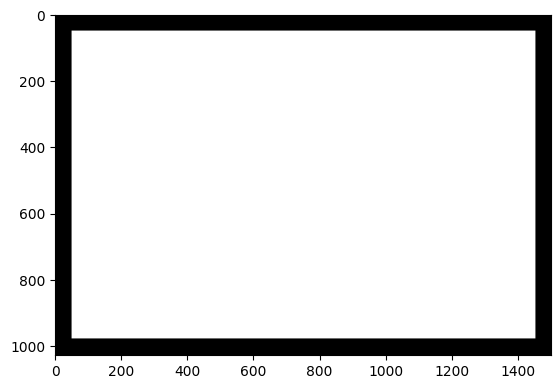

In [7]:
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# Mở ảnh và chuyển sang ảnh xám
data = Image.open('exercise/dalat.jpg').convert('L')

# Chuyển ảnh sang mảng numpy
data_np = np.array(data)

# Định nghĩa phần tử cấu trúc (structuring element)
s = np.array([[0, 1, 0],
              [1, 1, 1],
              [0, 1, 0]])

# Thực hiện phép đóng (closing) 50 lần
b = nd.binary_closing(data_np, structure=s, iterations=50)

# Chuyển kết quả thành ảnh để hiển thị
c = Image.fromarray((b * 255).astype(np.uint8))

# Hiển thị kết quả
c.show()                # Hiển thị bằng trình xem ảnh mặc định
plt.imshow(c, cmap='gray')   # Hiển thị bằng matplotlib
plt.show()


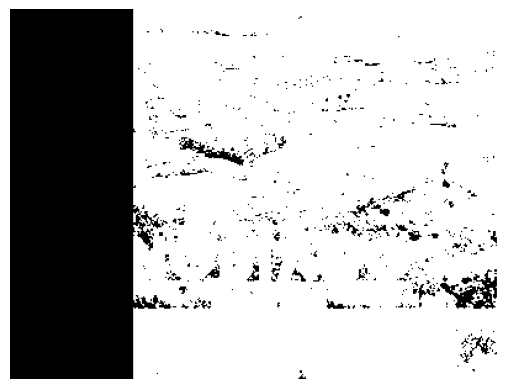

In [11]:
from PIL import Image
import numpy as np
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

# Bước 1: Đọc ảnh từ thư mục exercise
img = Image.open('exercise/dalat.jpg').convert('L')  # chuyển ảnh sang xám

# Bước 2: Cắt (ví dụ: chọn vùng LangBiang)
# Bạn cần biết tọa độ vùng chứa LangBiang trong ảnh. Ví dụ:
left, upper, right, lower = 200, 100, 500, 400
crop = img.crop((left, upper, right, lower))

# Bước 3: Tịnh tiến vùng chọn sang phải 100px
crop_array = np.array(crop)
h, w = crop_array.shape
new_w = w + 100
translated = np.zeros((h, new_w), dtype=crop_array.dtype)
translated[:, 100:] = crop_array

# Bước 4: Áp dụng Otsu hoặc ngưỡng thủ công 0.3
# (ngưỡng 0.3 dựa trên max pixel value 255 → 0.3*255)
threshold = 0.3 * 255
binary = (translated > threshold).astype(np.uint8) * 255

# Bước 5: Lưu và hiển thị
result_img = Image.fromarray(binary)
result_img.save('lang_biang.jpg')

# Hiển thị
plt.imshow(result_img, cmap='gray')
plt.axis('off')
plt.show()


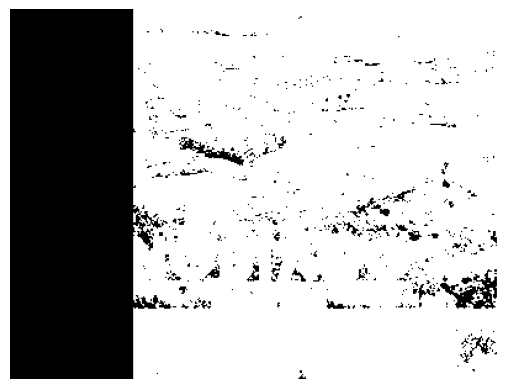

In [10]:

from PIL import Image
import numpy as np
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

# Bước 1: Đọc ảnh từ thư mục exercise
img = Image.open('exercise/dalat.jpg').convert('L')  # chuyển ảnh sang xám

# Bước 2: Cắt (ví dụ: chọn vùng LangBiang)
# Bạn cần biết tọa độ vùng chứa LangBiang trong ảnh. Ví dụ:
left, upper, right, lower = 200, 100, 500, 400
crop = img.crop((left, upper, right, lower))

# Bước 3: Tịnh tiến vùng chọn sang phải 100px
crop_array = np.array(crop)
h, w = crop_array.shape
new_w = w + 100
translated = np.zeros((h, new_w), dtype=crop_array.dtype)
translated[:, 100:] = crop_array

# Bước 4: Áp dụng Otsu hoặc ngưỡng thủ công 0.3
# (ngưỡng 0.3 dựa trên max pixel value 255 → 0.3*255)
threshold = 0.3 * 255
binary = (translated > threshold).astype(np.uint8) * 255

# Bước 5: Lưu và hiển thị
result_img = Image.fromarray(binary)
result_img.save('lang_biang.jpg')

# Hiển thị
plt.imshow(result_img, cmap='gray')
plt.axis('off')
plt.show()



Chọn chức năng:
geometric_transformation:
    1. coordinate_mapping
    2. Rotate
    3. Scale
    4. Shift
segment:
    5. Adaptive_thresholding
    6. Binary_dilation
    7. Binary_erosion
    8. Otsu

Đang chạy coordinate_mapping (demo: không làm gì)
Đang chạy binary_dilation với iterations=5


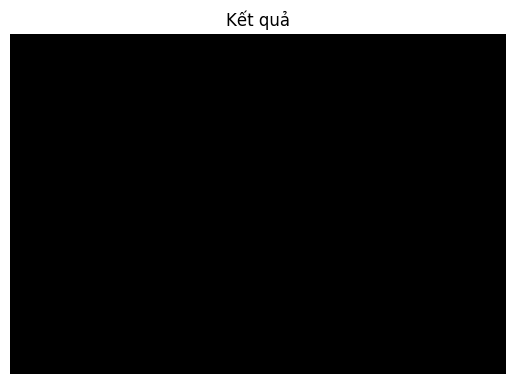

In [14]:
import cv2
import numpy as np
from PIL import Image
from skimage.filters import threshold_local, threshold_otsu
import scipy.ndimage as nd
import matplotlib.pyplot as plt

# Các hàm xử lý ảnh mẫu:
def coordinate_mapping(img):
    print("Đang chạy coordinate_mapping (demo: không làm gì)")
    return img

def rotate(img, angle=45):
    print(f"Đang xoay {angle} độ")
    (h, w) = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
    return cv2.warpAffine(img, M, (w, h))

def scale(img, fx=1.5, fy=1.5):
    print(f"Đang scale với fx={fx}, fy={fy}")
    return cv2.resize(img, None, fx=fx, fy=fy)

def shift(img, tx=50, ty=50):
    print(f"Đang dịch ảnh sang phải {tx}px, xuống {ty}px")
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]))

def adaptive_thresholding(img):
    print("Đang chạy adaptive_thresholding")
    return cv2.adaptiveThreshold(
        cv2.cvtColor(img, cv2.COLOR_BGR2GRAY),
        255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2
    )

def binary_dilation(img, iterations=5):
    print(f"Đang chạy binary_dilation với iterations={iterations}")
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return nd.binary_dilation(img_gray, iterations=iterations).astype(np.uint8) * 255

def binary_erosion(img, iterations=5):
    print(f"Đang chạy binary_erosion với iterations={iterations}")
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return nd.binary_erosion(img_gray, iterations=iterations).astype(np.uint8) * 255

def otsu(img):
    print("Đang chạy Otsu")
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    thresh = threshold_otsu(img_gray)
    return (img_gray > thresh).astype(np.uint8) * 255

# Tạo menu
print("""
Chọn chức năng:
geometric_transformation:
    1. coordinate_mapping
    2. Rotate
    3. Scale
    4. Shift
segment:
    5. Adaptive_thresholding
    6. Binary_dilation
    7. Binary_erosion
    8. Otsu
""")

# Đọc ảnh gốc
image_path = 'exercise/dalat.jpg'  # sửa lại đường dẫn nếu cần
img = cv2.imread(image_path)

# Nhập lựa chọn
choices = input("Nhập số chức năng muốn chạy (cách nhau bằng dấu cách, ví dụ: 2 8): ").split()

# Xử lý ảnh theo lựa chọn
result = img.copy()

for choice in choices:
    if choice == '1':
        result = coordinate_mapping(result)
    elif choice == '2':
        result = rotate(result)
    elif choice == '3':
        result = scale(result)
    elif choice == '4':
        result = shift(result)
    elif choice == '5':
        result = adaptive_thresholding(result)
    elif choice == '6':
        result = binary_dilation(result)
    elif choice == '7':
        result = binary_erosion(result)
    elif choice == '8':
        result = otsu(result)

# Hiển thị kết quả
plt.imshow(result, cmap='gray' if len(result.shape)==2 else None)
plt.title("Kết quả")
plt.axis('off')
plt.show()
